# **Quality Data Dengan Simple Data Profiling**

Pada bagian sebelumnya sudah mempelajari mengenai exploratory data analysis, dimana Exploratory Data Analysis (EDA) adalah menggunakan pendekatan statistik yang bertujuan untuk menemukan dan meringkas sebuah dataset, mengetahui struktur dan hubungan antar variabel dalam dataset. EDA merupakan proses pre-analysis baik untuk descriptive analysis maupun predictive analysis.

Dalam bab ini, aku akan fokus pada satu aspek EDA, yaitu: Data Profiling!

Data profiling adalah kegiatan merangkum dataset menggunakan statistik deskriptif. Tujuan dari pembuatan data profiling adalah untuk memiliki pemahaman yang kuat tentang data sehingga dapat mulai menyusun framework analisis  dan memvisualisasikan data.


![Kode Membaca file CSV](https://github.com/rahmadsa/Data-Wrangling-With-Python/blob/main/properties/img/data_profeling.png?raw=true)



## **Langkah - Langkah Profiling Data**

1. Importing Data

Sebagai langkah pertama yang harus dilakukan adalah inisialisasi Library dan mengimport dataset tersebut ke dalam Python menggunakan library Pandas dan diassign sebagai retail_raw.

2. Inspeksi tipe data

Dengan library Pandas, dapat menjalankan fungsi .dtypes untuk melihat data untuk setiap kolom termasuk tipe datanya.

3. Penerapan metode Profiling

Salah satu metode yang bisa digunakan untuk memahami struktur sata adalah Descriptive Statistics

4. Penggunaan Profiling Libraries

Melakukan statistik deskriptif dapat menjadi proses yang panjang. Penggunaan Pandas Profiling library memiliki function yang dapat membuat profiling data secara otomatis.

Untuk dapat menggunakannya, cukup dengan memanggil library:


```python
 import pandas_profiling
```




Kamu bisa memprosesnya dengan cara berikut:
1. Import dataset csv

    Import dataset csv ke variable bernama uncleaned_raw

2. Inspeksi Data Frame

    Inspeksi dataframe uncleaned_raw

3. Check kolom

    Check kolom yang mengandung missing value. Jika ada, kolom apakah itu dan berapa persen missing value pada kolom tersebut?
4. Mengisi missing value   
    Mengisi missing value tersebut dengan mean dari kolom tersebut!


**Kode Program 7.1**

```python
import pandas as pd
import numpy as np
import io

# Baca dataset uncleaned_raw.csv
uncleaned_raw = pd.read_csv('https://github.com/rahmadsa/dataset/blob/main/uncleaned_raw.csv')

#inspeksi dataframe uncleaned_raw
print('Lima data teratas:')
print(uncleaned_raw.head())

#Check kolom yang mengandung missing value
print('\nKolom dengan missing value:')
print(uncleaned_raw.isnull().any())


#Persentase missing value
length_qty = len(uncleaned_raw['Quantity'])
count_qty = uncleaned_raw['Quantity'].count()

#mengurangi length dengan count
number_of_missing_values_qty = length_qty - count_qty  

#mengubah ke bentuk float
#ratio_of_missing_values_product_id = number_of_missing_values_product_id / length_product_id
float_of_missing_values_qty = float(number_of_missing_values_qty / length_qty)

#mengubah ke dalam bentuk persen
pct_of_missing_values_qty = '{0:.1f}%'.format(float_of_missing_values_qty*100)

#print hasil percent dari missing value
print('Persentase missing value kolom Quantity:', pct_of_missing_values_qty)

#Mengisi missing value tersebut dengan mean dari kolom tersebut
uncleaned_raw['Quantity'] = uncleaned_raw['Quantity'].fillna(uncleaned_raw.Quantity.mean())

```

4. Mengisi missing value   
    Mengisi missing value tersebut dengan mean dari kolom tersebut! Mengetahui kolom yang memiliki outliers bisa menggunakan visualisasi dengan boxplot pada dataframe uncleaned_raw.

**Kode Program 7.2**

```python
import pandas as pd
import numpy as np
import io
import matplotlib.pyplot as plt

plt.style.use('default')

uncleaned_raw = pd.read_csv('https://github.com/rahmadsa/dataset/blob/main/uncleaned_raw.csv?raw=true')

uncleaned_raw['Quantity'] = uncleaned_raw['Quantity'].fillna(uncleaned_raw['Quantity'].mean())

#Mengetahui kolom yang memiliki outliers!
uncleaned_raw.boxplot()
#uncleaned_raw.___
plt.show()
```




### *Case Study:* Data Cleansing - Part 2

Langkah selanjutnya bisa dilakukan dengan cara berikut:

6. Removing outliers   

    Melakukan proses removing outliers pada kolom UnitPrice.
    
7. Checking duplikasi

    Checking duplikasi dan melakukan deduplikasi dataset tersebut!

    **Kode Program 7.3**


In [ ]:
mport pandas as pd
import numpy as np
import io

# Baca dataset uncleaned_raw.csv
uncleaned_raw = pd.read_csv('https://uncleaned_raw.csv')

#Check IQR
Q1 = uncleaned_raw['UnitPrice'].quantile(0.25)
Q3 = uncleaned_raw['UnitPrice'].quantile(0.75)
IQR = Q3 - Q1

#removing outliers
uncleaned_raw = uncleaned_raw[~((uncleaned_raw[['UnitPrice']] < (Q1 - 1.5 * IQR)) | (uncleaned_raw[['UnitPrice']] > (Q3 + 1.5 * IQR)))]

#check for duplication
print(uncleaned_raw.duplicated(subset=None))

#remove duplication
uncleaned_raw = uncleaned_raw.drop_duplicates()

**Tugas Praktik 7:**

Amati dan pahami proses EDA dengan menjalankan script **Kode Program 7.1** , **Kode Program 7.2**, **Kode Program 7.3** pada cell editor dibawah ini lakukan debuging jika perlu.


LIMA DATA TERATAS:
   InvoiceNo                          Description  Quantity     InvoiceDate  \
0     536365   WHITE HANGING HEART T-LIGHT HOLDER       6.0  12/01/10 08.26   
1     536366                  WHITE METAL LANTERN       6.0  12/01/10 08.26   
2     536367       CREAM CUPID HEARTS COAT HANGER       8.0  12/01/10 08.26   
3     536368  KNITTED UNION FLAG HOT WATER BOTTLE       6.0  12/01/10 08.26   
4     536369       RED WOOLLY HOTTIE WHITE HEART.       6.0  12/01/10 08.26   

   UnitPrice  CustomerID      City  
0      29000       17850  Surabaya  
1      41000       17850  Surabaya  
2      18000       17850  Surabaya  
3      38000       17850   Jakarta  
4      27000       17850     Medan  
KOLOM DENGAN MISSING VALUE:
InvoiceNo      False
Description    False
Quantity        True
InvoiceDate    False
UnitPrice      False
CustomerID     False
City           False
dtype: bool
HASIL ANALISIS MISSING VALUE:
Persentase missing value kolom Quantity: 4.0%
Missing value pada ko

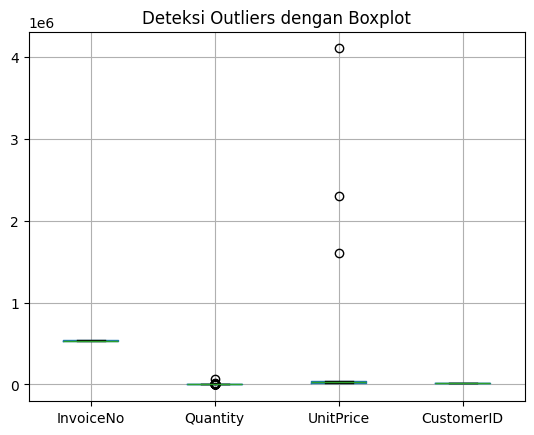

PROSES CLEANING: REMOVING OUTLIERS & DEDUPLIKASI
Jumlah baris data yang duplikat sebelum dihapus: 6
Proses deduplikasi selesai. Jumlah baris data saat ini: 496


In [2]:
#Tugas Praktik 7.1
import pandas as pd
import numpy as np

# Perbaikan URL agar mengarah langsung ke raw file GitHub
url_data = 'https://raw.githubusercontent.com/rahmadsa/dataset/main/uncleaned_raw.csv'
uncleaned_raw = pd.read_csv(url_data)

# Inspeksi dataframe uncleaned_raw
print('LIMA DATA TERATAS:')
print(uncleaned_raw.head())

# Check kolom yang mengandung missing value
print('KOLOM DENGAN MISSING VALUE:')
print(uncleaned_raw.isnull().any())

# Persentase missing value pada kolom Quantity
length_qty = len(uncleaned_raw['Quantity'])
count_qty = uncleaned_raw['Quantity'].count()

# Mengurangi length dengan count untuk mendapatkan jumlah nilai yang hilang
number_of_missing_values_qty = length_qty - count_qty

# Mengubah ke bentuk rasio float
float_of_missing_values_qty = float(number_of_missing_values_qty / length_qty)

# Mengubah ke dalam bentuk persen string
pct_of_missing_values_qty = '{0:.1f}%'.format(float_of_missing_values_qty * 100)

print('HASIL ANALISIS MISSING VALUE:')
print('Persentase missing value kolom Quantity:', pct_of_missing_values_qty)

# Mengisi missing value tersebut dengan mean dari kolom tersebut
uncleaned_raw['Quantity'] = uncleaned_raw['Quantity'].fillna(uncleaned_raw['Quantity'].mean())
print("Missing value pada kolom Quantity berhasil diisi dengan nilai Mean.")


# Tugas Praktik 7.2
import matplotlib.pyplot as plt

print('VISUALISASI OUTLIERS (BOXPLOT):')

plt.style.use('default')

# Menampilkan grafik boxplot untuk mendeteksi pencilan/outliers
uncleaned_raw.boxplot()
plt.title("Deteksi Outliers dengan Boxplot")
plt.show()


# Tugas Praktik 7.3
print('PROSES CLEANING: REMOVING OUTLIERS & DEDUPLIKASI')

# Perbaikan Sintaks IQR dari Kolom UnitPrice
Q1 = uncleaned_raw['UnitPrice'].quantile(0.25)
Q3 = uncleaned_raw['UnitPrice'].quantile(0.75)
IQR = Q3 - Q1

# Batas bawah dan batas atas toleransi data
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

# Proses menghilangkan/filter data yang berada di luar batas IQR (Removing Outliers)
# Filter diaplikasikan langsung pada kesatuan dataframe agar indeks baris sinkron
uncleaned_raw = uncleaned_raw[(uncleaned_raw['UnitPrice'] >= batas_bawah) & (uncleaned_raw['UnitPrice'] <= batas_atas)]

# Mengecek nilai duplikasi dalam bentuk ringkasan total baris yang kembar
print("Jumlah baris data yang duplikat sebelum dihapus:", uncleaned_raw.duplicated().sum())

# Melakukan proses penghapusan data duplikat (Deduplikasi)
uncleaned_raw = uncleaned_raw.drop_duplicates()
print("Proses deduplikasi selesai. Jumlah baris data saat ini:", len(uncleaned_raw))